In [ ]:
# STEP 1: IMPORT LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#to define & train MLP model
from tensorflow import keras
#feedforward neural network
from tensorflow.keras.models import Sequential
#optimizer
from tensorflow.keras.optimizers import Adam
#this is fully connected layer with regularization(dropout)
from tensorflow.keras.layers import Dense,Dropout


In [ ]:
# STEP 2: LOAD THE DATASET

from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Project CompBio/diabetes_prediction_dataset.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

Mounted at /content/drive
First 5 rows of the dataset:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [ ]:
# STEP 3: EDA: DATASET OVERVIEW

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset infrmation:")
df.info()

print("Missing values in each column:")
print(df.isnull().sum())

target_column = 'diabetes'

#Separate input features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Dataset shape: (100000, 9)

Column names:
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Dataset infrmation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
Missing values in each column:
gender     

In [ ]:
# STEP 4: EDA: STATISTICAL SUMMARY

print("Summary statistics of the dataset:")
print(X.describe())

Summary statistics of the dataset:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level  
count  100000.000000        100000.000000  
mean        5.527507           138.058060  
std         1.070672            40.708136  
min         3.500000            80.000000  
25%         4.800000           100.000000  
50%         5.800000           140.000000  
75%         6.200000           159.000000  


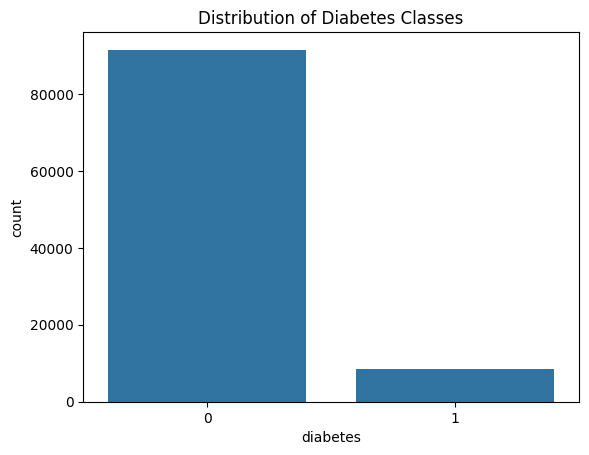

In [ ]:
# STEP 5: EDA: CLASS DISTRIBUTION

# Count plot for target variable
sns.countplot(x='diabetes', data=df)
plt.title("Distribution of Diabetes Classes")
plt.show()

In [ ]:
# STEP 6: EDA: DATA VISUALIZATION: ENCODE TARGET LABELS

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded class labels:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

Encoded class labels:
0 --> 0
1 --> 1


In [ ]:
# STEP 7: EDA: DATA VISUALIZATION: FEATURE SELECTION USING VARIANCE

# Identify numerical columns for variance calculation
numeric_cols = X.select_dtypes(include=['number']).columns

# Compute variance of each numerical feature
feature_variance = X[numeric_cols].var()

# Select top 1000 most variable features
# Note: Given the dataset, there are fewer than 1000 features,
# so this will select all numerical features by default.
top_features = feature_variance.sort_values(ascending=False).head(1000).index

# Keep only the selected features
X_selected = X[top_features]

print("Original feature shape:", X.shape)
print("Selected feature shape:", X_selected.shape)

Original feature shape: (100000, 8)
Selected feature shape: (100000, 6)


In [ ]:
# STEP 8: EDA: DATA VISUALIZATION: SPLIT THE DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 6)
X_test shape: (20000, 6)
y_train shape: (80000,)
y_test shape: (20000,)


In [ ]:
# STEP 9: EDA: DATA VISUALIZATION: FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training_shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training_shape: (80000, 6)
Scaled testing shape: (20000, 6)


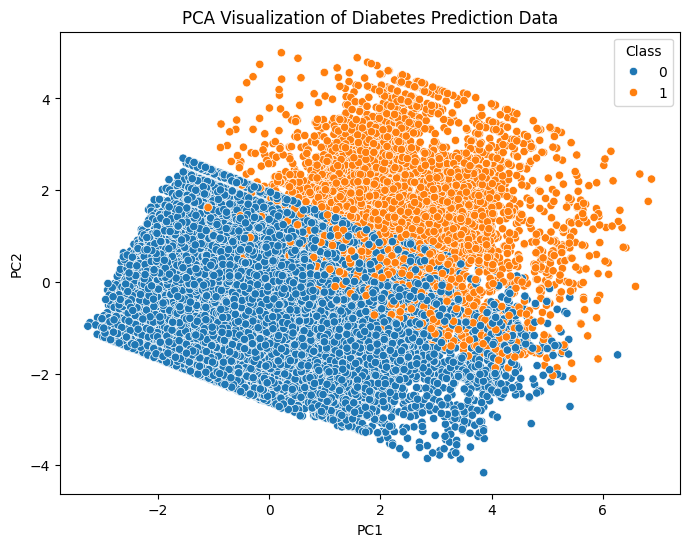

In [ ]:
# STEP 10: EDA: DATA VISUALIZATION: PCA FOR 2D VISUALIZATION

pca_vis = PCA(n_components=2)
X_pca = pca_vis.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['Class'] = y_train

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Class', palette='tab10')
plt.title("PCA Visualization of Diabetes Prediction Data")
plt.show()